# 04 — Empirical decision analysis
Applies the loss-sensitive decision rule to all empirical models.

In [1]:
# !pip -q install pandas numpy matplotlib openpyxl
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJECT_ROOT = "/content/outputs"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
TAB_DIR = os.path.join(PROJECT_ROOT, "tables")
INT_DIR = os.path.join(PROJECT_ROOT, "intermediate")
for d in [PROJECT_ROOT, FIG_DIR, TAB_DIR, INT_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH = "analytic_cohort_for_modeling.csv"
COL_HOSPITAL = "hospital_hash"
COL_BRAND = "brand_hash"
COL_AGE = "age_at_year"
COL_CM = "cm_count"
COL_DT = "total_downtime_hours"
COL_Y = "high_downtime_t_plus_1"
TEST_SIZE_HOSPITALS = 0.25
RANDOM_STATE = 42

,Scenario,Model,Avg. expected loss,Avg. realized loss,Keep rate,Inspect rate,Replace rate,Positive rate among kept,Positive rate among inspected,Positive rate among replaced
0,Inspection-favored,Age-only heuristic,0.124902,0.115338,0.185694,0.776095,0.038211,0.107905,0.165416,0.189024
1,Inspection-favored,Age + maintenance heuristic,0.107748,0.110989,0.285415,0.685927,0.028658,0.088163,0.177649,0.300813
2,Inspection-favored,Logistic regression,0.135920,0.106408,0.000000,0.998369,0.001631,NaN,0.154726,0.714286
3,Inspection-favored,Gradient boosting,0.136693,0.106849,0.000932,0.993942,0.005126,0.000000,0.154712,0.363636
4,Inspection-favored,Hierarchical Bayesian model,0.137245,0.106343,0.000000,0.999068,0.000932,NaN,0.154851,1.000000
5,Balanced,Age-only heuristic,0.127946,0.144578,0.279124,0.450839,0.270037,0.118531,0.170543,0.169111
6,Balanced,Age + maintenance heuristic,0.112347,0.126680,0.460624,0.325489,0.213886,0.102175,0.132427,0.306100
7,Balanced,Logistic regression,0.155938,0.130476,0.000000,0.807782,0.192218,NaN,0.114220,0.329697
8,Balanced,Gradient boosting,0.155922,0.130424,0.010951,0.797064,0.191985,0.127660,0.113709,0.331311
9,Balanced,Hierarchical Bayesian model,0.159723,0.130264,0.000000,0.838537,0.161463,NaN,0.120311,0.339105


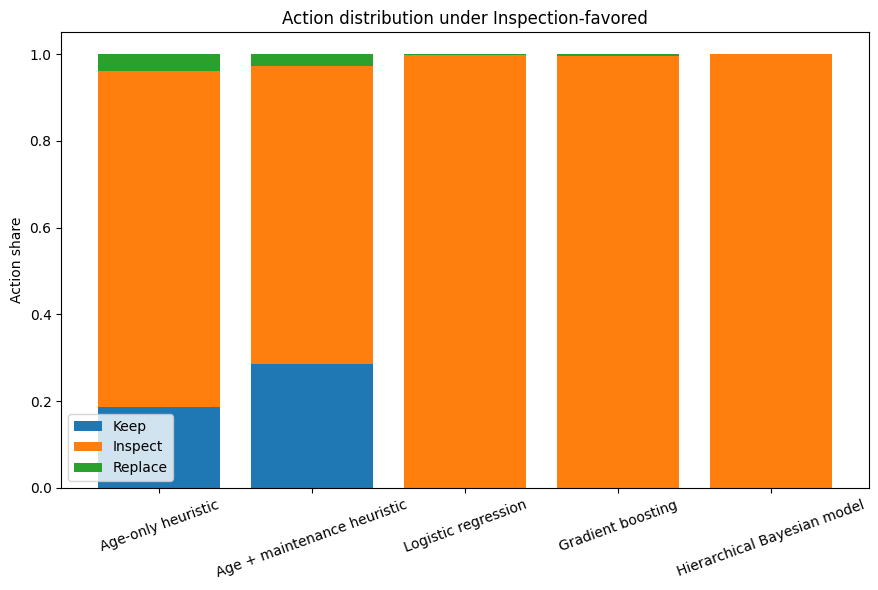

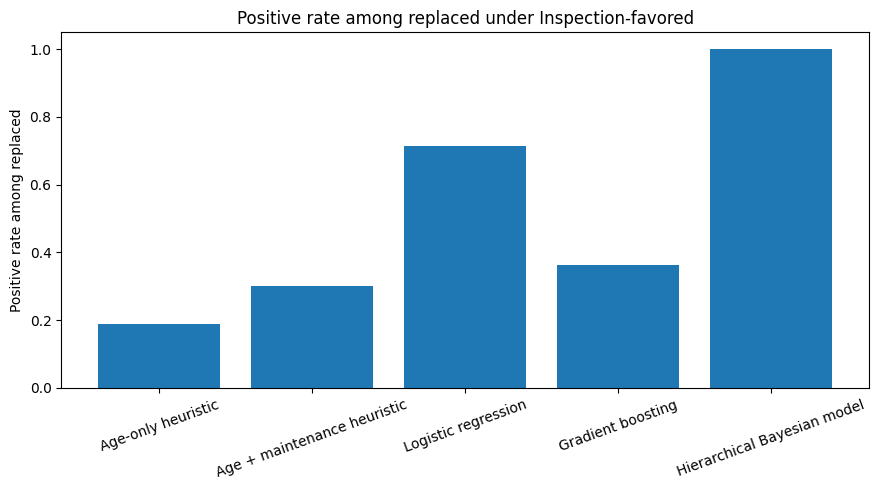

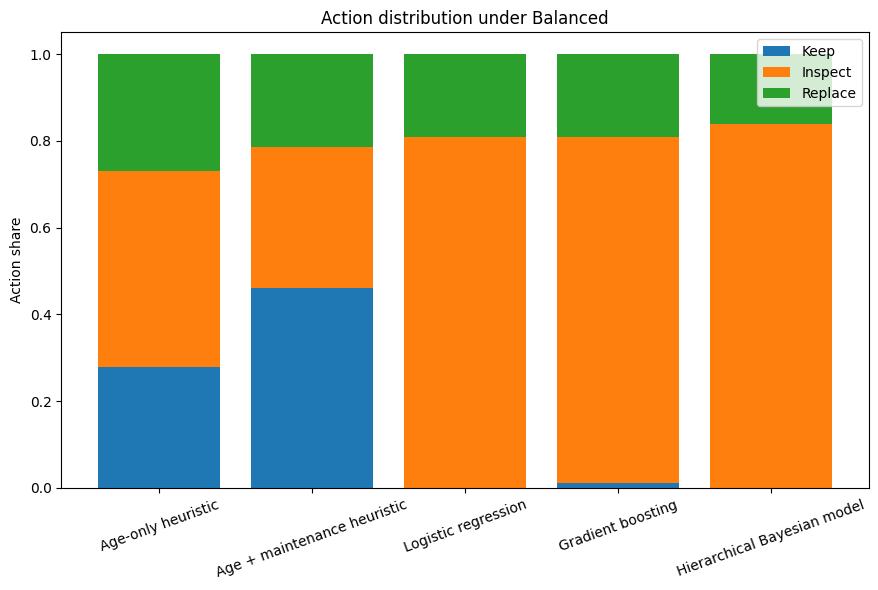

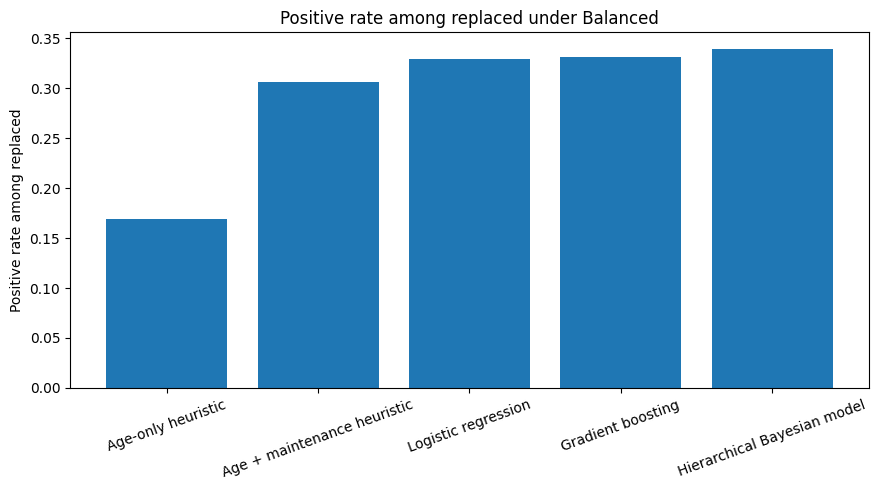

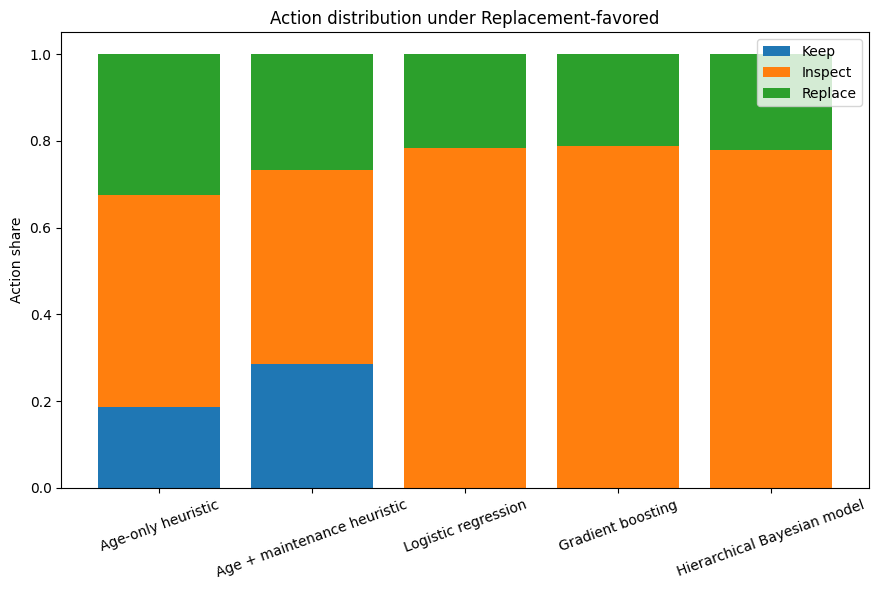

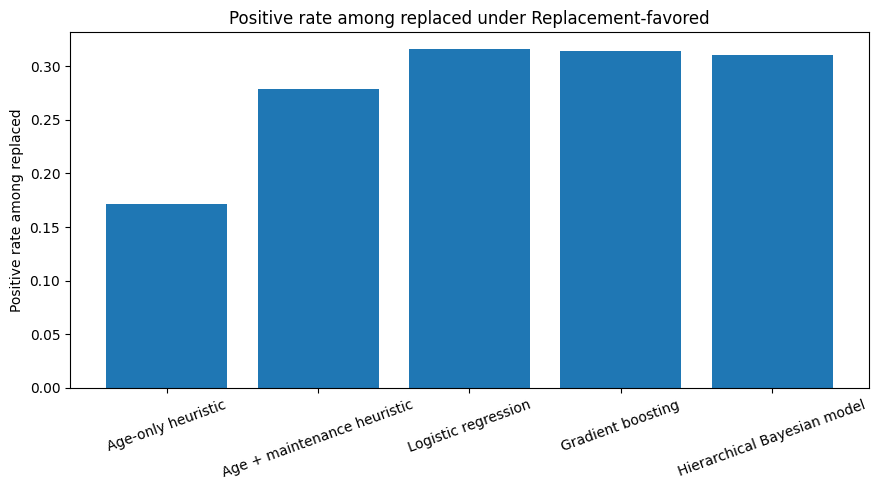

Done.


In [2]:
LOSS_SCENARIOS = {
    "Inspection-favored": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.052, "c_R": 0.262},
    "Balanced": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.078, "c_R": 0.183},
    "Replacement-favored": {"lambda_K": 1.0, "lambda_I": 0.35, "c_I": 0.052, "c_R": 0.145},
}

bench = pd.read_csv(os.path.join(INT_DIR, "benchmark_test_predictions.csv"))
bayes = pd.read_csv(os.path.join(INT_DIR, "bayesian_test_predictions.csv"))
decision_df = bench.copy()
decision_df["Hierarchical Bayesian model"] = bayes["Hierarchical Bayesian model"].values
models = ["Age-only heuristic", "Age + maintenance heuristic", "Logistic regression", "Gradient boosting", "Hierarchical Bayesian model"]
y_test = decision_df[COL_Y].values

def expected_loss_actions(p, params):
    loss_keep = params["lambda_K"] * p
    loss_inspect = params["c_I"] + params["lambda_I"] * p
    loss_replace = np.full_like(p, params["c_R"], dtype=float)
    losses = np.vstack([loss_keep, loss_inspect, loss_replace]).T
    action_idx = np.argmin(losses, axis=1)
    return action_idx, losses[np.arange(len(p)), action_idx]

def realized_loss(y, action_idx, params):
    loss = np.zeros_like(y, dtype=float)
    loss[action_idx == 0] = params["lambda_K"] * y[action_idx == 0]
    loss[action_idx == 1] = params["c_I"] + params["lambda_I"] * y[action_idx == 1]
    loss[action_idx == 2] = params["c_R"]
    return loss

rows = []
for scenario_name, params in LOSS_SCENARIOS.items():
    for model_name in models:
        p = decision_df[model_name].values
        action_idx, exp_loss = expected_loss_actions(p, params)
        rloss = realized_loss(y_test, action_idx, params)
        def pos_rate(code):
            m = action_idx == code
            return np.nan if m.sum() == 0 else y_test[m].mean()
        rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Avg. expected loss": exp_loss.mean(),
            "Avg. realized loss": rloss.mean(),
            "Keep rate": np.mean(action_idx == 0),
            "Inspect rate": np.mean(action_idx == 1),
            "Replace rate": np.mean(action_idx == 2),
            "Positive rate among kept": pos_rate(0),
            "Positive rate among inspected": pos_rate(1),
            "Positive rate among replaced": pos_rate(2),
        })
decision_summary = pd.DataFrame(rows)
display(decision_summary)
decision_summary.to_csv(os.path.join(TAB_DIR, "table_decision_outcomes.csv"), index=False)
with open(os.path.join(TAB_DIR, "table_decision_outcomes.tex"), "w") as f:
    f.write(decision_summary.to_latex(index=False, float_format="%.3f"))

for scenario_name in LOSS_SCENARIOS.keys():
    tmp = decision_summary[decision_summary["Scenario"] == scenario_name].copy()
    x = np.arange(len(tmp))
    keep, inspect, replace = tmp["Keep rate"].values, tmp["Inspect rate"].values, tmp["Replace rate"].values
    plt.figure(figsize=(9,6))
    plt.bar(x, keep, label="Keep")
    plt.bar(x, inspect, bottom=keep, label="Inspect")
    plt.bar(x, replace, bottom=keep+inspect, label="Replace")
    plt.xticks(x, tmp["Model"], rotation=20)
    plt.ylabel("Action share"); plt.title(f"Action distribution under {scenario_name}")
    plt.legend(); plt.tight_layout()
    fname = f"figure_decision_action_distribution_{scenario_name.lower().replace(' ', '_')}.png"
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300)
    plt.show()

    plt.figure(figsize=(9,5))
    plt.bar(x, tmp["Positive rate among replaced"].values)
    plt.xticks(x, tmp["Model"], rotation=20)
    plt.ylabel("Positive rate among replaced"); plt.title(f"Positive rate among replaced under {scenario_name}")
    plt.tight_layout()
    fname = f"figure_positive_rate_replaced_{scenario_name.lower().replace(' ', '_')}.png"
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=300)
    plt.show()
print("Done.")

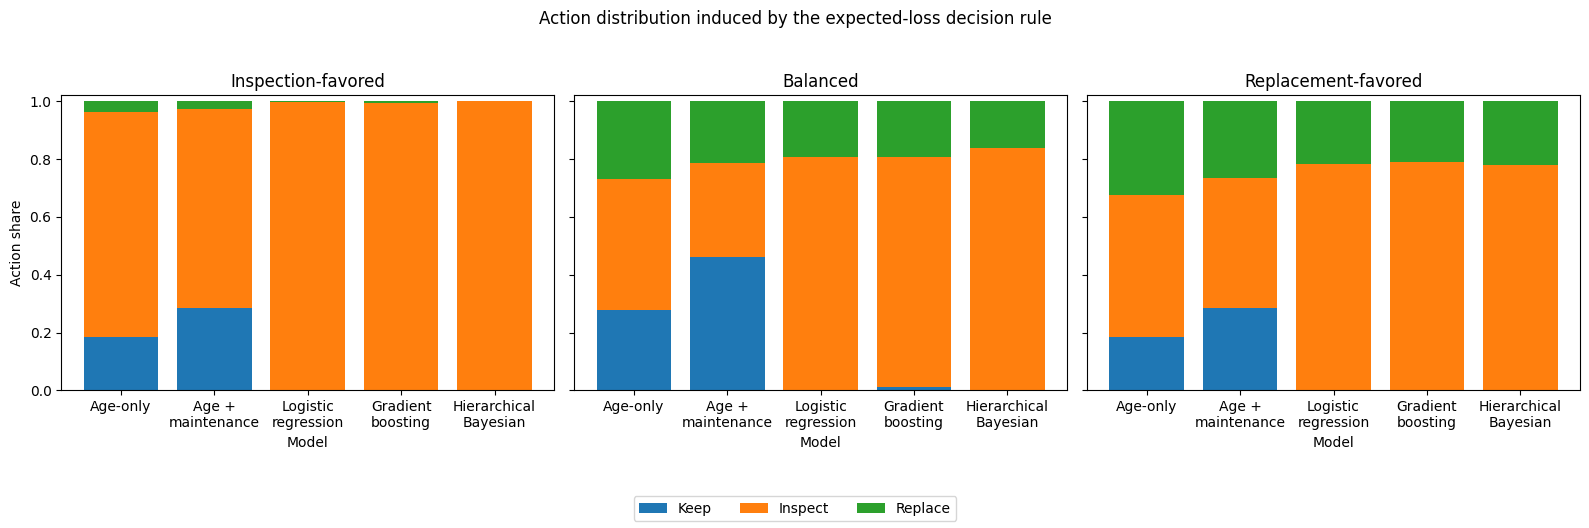

In [3]:
# ============================================================
# Publication-ready decision action distribution figure
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# Shorter labels for plotting
model_label_map = {
    "Age-only heuristic": "Age-only",
    "Age + maintenance heuristic": "Age +\nmaintenance",
    "Logistic regression": "Logistic\nregression",
    "Gradient boosting": "Gradient\nboosting",
    "Hierarchical Bayesian model": "Hierarchical\nBayesian",
}

scenario_order = [
    "Inspection-favored",
    "Balanced",
    "Replacement-favored"
]

action_cols = ["Keep rate", "Inspect rate", "Replace rate"]
action_labels = ["Keep", "Inspect", "Replace"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, scenario_name in zip(axes, scenario_order):
    tmp = decision_summary[decision_summary["Scenario"] == scenario_name].copy()
    tmp["Plot label"] = tmp["Model"].map(model_label_map)

    x = np.arange(len(tmp))
    keep = tmp["Keep rate"].values
    inspect = tmp["Inspect rate"].values
    replace = tmp["Replace rate"].values

    ax.bar(x, keep, label="Keep")
    ax.bar(x, inspect, bottom=keep, label="Inspect")
    ax.bar(x, replace, bottom=keep + inspect, label="Replace")

    ax.set_title(scenario_name)
    ax.set_xticks(x)
    ax.set_xticklabels(tmp["Plot label"], rotation=0)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Model")

axes[0].set_ylabel("Action share")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True)

plt.suptitle("Action distribution induced by the expected-loss decision rule", y=1.03)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(os.path.join(FIG_DIR, "figure_decision_action_distribution_panel.png"), dpi=300, bbox_inches="tight")
plt.show()

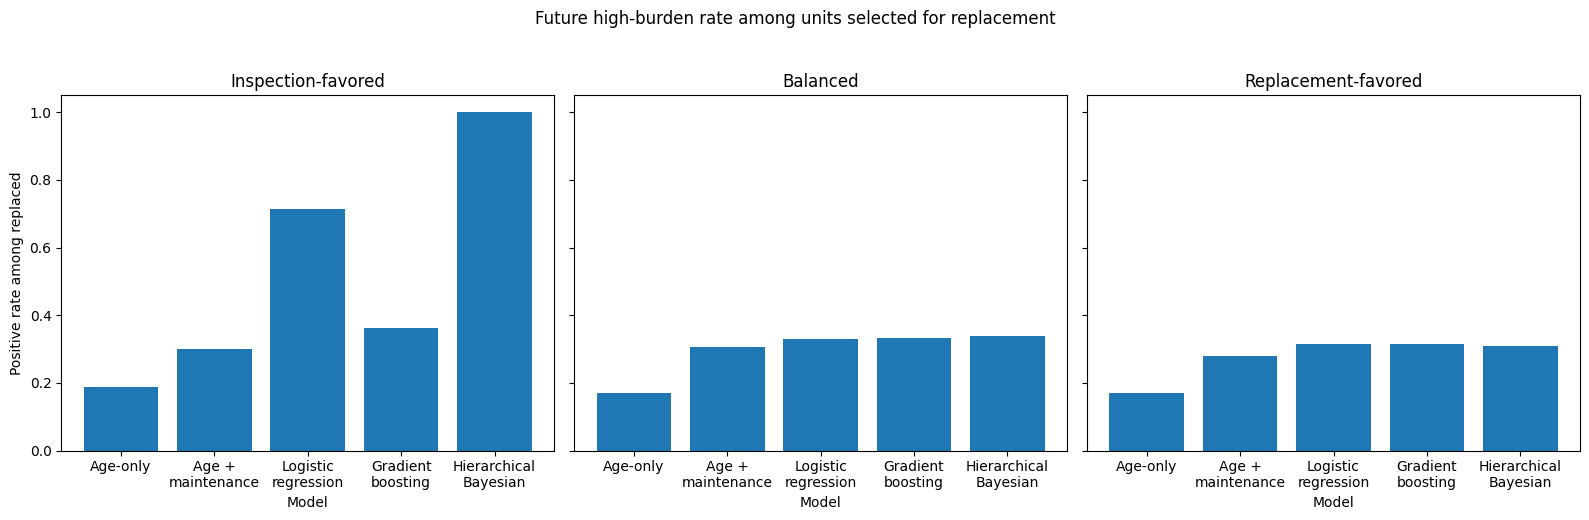

In [4]:
# ============================================================
# Supplementary figure: positive rate among replaced
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, scenario_name in zip(axes, scenario_order):
    tmp = decision_summary[decision_summary["Scenario"] == scenario_name].copy()
    tmp["Plot label"] = tmp["Model"].map(model_label_map)

    x = np.arange(len(tmp))
    values = tmp["Positive rate among replaced"].values

    ax.bar(x, values)
    ax.set_title(scenario_name)
    ax.set_xticks(x)
    ax.set_xticklabels(tmp["Plot label"], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Model")

axes[0].set_ylabel("Positive rate among replaced")

plt.suptitle("Future high-burden rate among units selected for replacement", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_positive_rate_replaced_panel.png"), dpi=300, bbox_inches="tight")
plt.show()